In [1]:
# Install dependencies

!pip install -q kaggle split-folders tensorflow scikit-learn seaborn

In [2]:
from tensorflow.keras.applications import ConvNeXtTiny

In [3]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
!pip install -q kagglehub

import kagglehub
import os

dataset_path = kagglehub.dataset_download(
    "gunavenkatdoddi/eye-diseases-classification"
)

print("Dataset downloaded successfully!")
print("Dataset path:", dataset_path)
print("Contents:", os.listdir(dataset_path))

100%|██████████| 736M/736M [00:34<00:00, 22.2MB/s]

Extracting files...


Dataset downloaded successfully!
Dataset path: /root/.cache/kagglehub/datasets/gunavenkatdoddi/eye-diseases-classification/versions/1
Contents: ['dataset']


In [5]:
# Download and extract the dataset using the Kaggle CLI (reads env vars automatically)

DATA_ROOT = "/content/eye_diseases_raw"
os.makedirs(DATA_ROOT, exist_ok=True)

!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification -p {DATA_ROOT} --force
!unzip -q -o {DATA_ROOT}/eye-diseases-classification.zip -d {DATA_ROOT}

# Inspect folder structure to find the actual class-folder root
for root, dirs, files in os.walk(DATA_ROOT):
    if files and any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in files):
        print(root, "->", len(files), "images")

Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
100% 736M/736M [00:40<00:00, 19.1MB/s]

/content/eye_diseases_raw/dataset/diabetic_retinopathy -> 1098 images
/content/eye_diseases_raw/dataset/cataract -> 1038 images
/content/eye_diseases_raw/dataset/glaucoma -> 1007 images
/content/eye_diseases_raw/dataset/normal -> 1074 images


In [6]:
# Imports

import shutil
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                              auc, precision_recall_fscore_support)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [7]:
# Locate the class-folder directory produced by the dataset

CANDIDATES = glob.glob(f"{DATA_ROOT}/**/dataset", recursive=True)
SOURCE_DIR = CANDIDATES[0] if CANDIDATES else DATA_ROOT
print("Using source directory:", SOURCE_DIR)
print("Classes found:", os.listdir(SOURCE_DIR))

Using source directory: /content/eye_diseases_raw/dataset
Classes found: ['diabetic_retinopathy', 'cataract', 'glaucoma', 'normal']


In [8]:
# Stratified train/val/test split (prevents data leakage - done ONCE, before any preprocessing)

SPLIT_DIR = "/content/eye_diseases_split"
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

splitfolders.ratio(
    SOURCE_DIR,
    output=SPLIT_DIR,
    seed=SEED,
    ratio=(0.70, 0.15, 0.15),   # train / val / test
    group_prefix=None,
    move=False
)

TRAIN_DIR = f"{SPLIT_DIR}/train"
VAL_DIR   = f"{SPLIT_DIR}/val"
TEST_DIR  = f"{SPLIT_DIR}/test"

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)

for split, d in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    counts = {c: len(os.listdir(os.path.join(d, c))) for c in CLASS_NAMES}
    print(split, counts)

Copying files: 4217 files [00:06, 678.13 files/s] 

Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
train {'cataract': 726, 'diabetic_retinopathy': 768, 'glaucoma': 704, 'normal': 751}
val {'cataract': 155, 'diabetic_retinopathy': 164, 'glaucoma': 151, 'normal': 161}
test {'cataract': 157, 'diabetic_retinopathy': 166, 'glaucoma': 152, 'normal': 162}


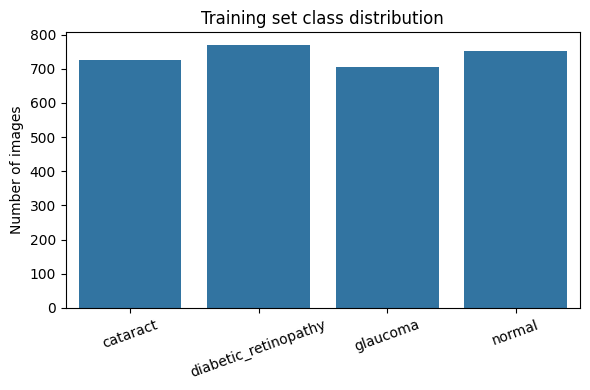

In [9]:
# Exploratory Data Analysis - class distribution plot

train_counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASS_NAMES}
plt.figure(figsize=(6, 4))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()))
plt.title("Training set class distribution")
plt.ylabel("Number of images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=150)
plt.show()

In [10]:
# Preprocessing pipeline for ConvNeXt-Tiny

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load the SAME train / validation / test splits
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)


# Data augmentation - training data only
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.12),
    layers.RandomBrightness(0.12),
], name="data_augmentation")


def make_pipeline(ds, training=False):

    ds = ds.map(
        lambda x, y: (tf.cast(x, tf.float32), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        # Do NOT cache after random augmentation.
        # This allows new augmentation each epoch.
        ds = ds.map(
            lambda x, y: (
                data_augmentation(x, training=True),
                y
            ),
            num_parallel_calls=tf.data.AUTOTUNE
        )

        return ds.prefetch(tf.data.AUTOTUNE)

    else:
        # Validation/test have no random augmentation,
        # therefore caching is safe.
        return ds.cache().prefetch(tf.data.AUTOTUNE)


train_ds = make_pipeline(train_ds_raw, training=True)
val_ds   = make_pipeline(val_ds_raw, training=False)
test_ds  = make_pipeline(test_ds_raw, training=False)


# Class weights from TRAINING split only
y_train_labels = []

for c_idx, c in enumerate(CLASS_NAMES):
    y_train_labels += [c_idx] * train_counts[c]

class_weights_arr = compute_class_weight(
    'balanced',
    classes=np.arange(NUM_CLASSES),
    y=np.array(y_train_labels)
)

class_weight_dict = dict(enumerate(class_weights_arr))

print("Class weights:", class_weight_dict)

Found 2949 files belonging to 4 classes.
Found 631 files belonging to 4 classes.
Found 637 files belonging to 4 classes.
Class weights: {0: np.float64(1.015495867768595), 1: np.float64(0.9599609375), 2: np.float64(1.0472301136363635), 3: np.float64(0.9816910785619174)}


In [11]:
# Build the ConvNeXt-Tiny model (transfer learning)

def build_convnext_tiny(num_classes, img_size=(224, 224)):

    # Pre-trained ConvNeXt-Tiny backbone
    base_model = ConvNeXtTiny(
        weights='imagenet',
        include_top=False,
        input_shape=img_size + (3,),
        include_preprocessing=True
    )

    # Phase 1: freeze the entire backbone
    base_model.trainable = False

    inputs = layers.Input(shape=img_size + (3,))

    # Do not permanently force training=False here.
    # Keras will handle training/inference mode appropriately.
    x = base_model(inputs)

    # Shared classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    )(x)

    x = layers.Dropout(0.45)(x)

    outputs = layers.Dense(
        num_classes,
        activation='softmax'
    )(x)

    model = models.Model(
        inputs,
        outputs,
        name="ConvNeXtTiny_EyeDisease"
    )

    return model, base_model


# Build model with frozen ImageNet backbone
model, base_model = build_convnext_tiny(
    NUM_CLASSES,
    IMG_SIZE
)

model.summary()

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "ConvNeXtTiny_EyeDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,021,092 (106.89 MB)

 Trainable params: 199,428 (779.02 KB)

 Non-trainable params: 27,821,664 (106.13 MB)

In [12]:
# ============================================================
# PHASE 1 - Train classification head only
# ============================================================

import time

# Make sure backbone is frozen
base_model.trainable = False

# Compile model
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    '/content/convnext_tiny_best_phase1.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Maximum Phase 1 epochs
EPOCHS_PHASE1 = 20

print("Starting ConvNeXt-Tiny Phase 1 training...")
print("Backbone trainable:", base_model.trainable)

# Start timer
phase1_start_time = time.perf_counter()

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weight_dict,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

# Stop timer
phase1_training_time = time.perf_counter() - phase1_start_time

print("\n======================================")
print("PHASE 1 COMPLETED")
print("======================================")
print(f"Epochs run          : {len(history_phase1.history['loss'])}")
print(f"Training time       : {phase1_training_time:.2f} seconds")
print(f"Training time       : {phase1_training_time/60:.2f} minutes")
print(
    f"Best validation acc : "
    f"{max(history_phase1.history['val_accuracy']):.4f}"
)
print(
    f"Best validation loss: "
    f"{min(history_phase1.history['val_loss']):.4f}"
)

Starting ConvNeXt-Tiny Phase 1 training...
Backbone trainable: False
Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.6532 - auc: 0.8625 - loss: 1.1036 - precision: 0.6773 - recall: 0.6219
Epoch 1: val_loss improved from None to 0.78415, saving model to /content/convnext_tiny_best_phase1.keras

Epoch 1: finished saving model to /content/convnext_tiny_best_phase1.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 92s 746ms/step - accuracy: 0.7141 - auc: 0.9074 - loss: 0.8904 - precision: 0.7343 - recall: 0.6935 - val_accuracy: 0.7353 - val_auc: 0.9156 - val_loss: 0.7841 - val_precision: 0.8277 - val_recall: 0.5864 - learning_rate: 0.0010
Epoch 2/20
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.7845 - auc: 0.9446 - loss: 0.6483 - precision: 0.8059 - recall: 0.7559
Epoch 2: val_loss improved from 0.78415 to 0.68766, saving model to /content/convnext_tiny_best_phase1.keras

Epoch 2: finished saving model to /content/convnext_tiny_best_phase1.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 46s 489

In [13]:
# ============================================================
# PHASE 2 - Fine-tune the last 20% of ConvNeXt-Tiny
# ============================================================

import time

# Unfreeze backbone
base_model.trainable = True

# Keep first 80% frozen
FINE_TUNE_AT = int(len(base_model.layers) * 0.80)

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

for layer in base_model.layers[FINE_TUNE_AT:]:
    layer.trainable = True

print("Total backbone layers       :", len(base_model.layers))
print("Fine-tuning starts at layer :", FINE_TUNE_AT)
print(
    "Trainable backbone layers   :",
    sum(layer.trainable for layer in base_model.layers)
)

# IMPORTANT: recompile after changing trainable layers
model.compile(
    optimizer=optimizers.Adam(learning_rate=8e-6),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

early_stop_ft = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_ft = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint_ft = callbacks.ModelCheckpoint(
    '/content/convnext_tiny_best_phase2.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

EPOCHS_PHASE2 = 15

print("\nStarting ConvNeXt-Tiny Phase 2 fine-tuning...")

phase2_start_time = time.perf_counter()

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    class_weight=class_weight_dict,
    callbacks=[
        early_stop_ft,
        reduce_lr_ft,
        checkpoint_ft
    ]
)

phase2_training_time = time.perf_counter() - phase2_start_time

total_training_time = (
    phase1_training_time +
    phase2_training_time
)

print("\n======================================")
print("PHASE 2 COMPLETED")
print("======================================")
print(f"Epochs run          : {len(history_phase2.history['loss'])}")
print(f"Training time       : {phase2_training_time:.2f} seconds")
print(f"Training time       : {phase2_training_time/60:.2f} minutes")
print(
    f"Best validation acc : "
    f"{max(history_phase2.history['val_accuracy']):.4f}"
)
print(
    f"Best validation loss: "
    f"{min(history_phase2.history['val_loss']):.4f}"
)

print("\n======================================")
print("TOTAL TRAINING")
print("======================================")
print(
    f"Total epochs : "
    f"{len(history_phase1.history['loss']) + len(history_phase2.history['loss'])}"
)
print(f"Total time   : {total_training_time:.2f} seconds")
print(f"Total time   : {total_training_time/60:.2f} minutes")

Total backbone layers       : 133
Fine-tuning starts at layer : 106
Trainable backbone layers   : 27

Starting ConvNeXt-Tiny Phase 2 fine-tuning...
Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.8709 - auc: 0.9807 - loss: 0.3701 - precision: 0.8888 - recall: 0.8599
Epoch 1: val_loss improved from None to 0.51060, saving model to /content/convnext_tiny_best_phase2.keras

Epoch 1: finished saving model to /content/convnext_tiny_best_phase2.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 97s 727ms/step - accuracy: 0.8749 - auc: 0.9803 - loss: 0.3728 - precision: 0.8900 - recall: 0.8667 - val_accuracy: 0.8146 - val_auc: 0.9647 - val_loss: 0.5106 - val_precision: 0.8287 - val_recall: 0.8051 - learning_rate: 8.0000e-06
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.8799 - auc: 0.9807 - loss: 0.3671 - precision: 0.8930 - recall: 0.8682
Epoch 2: val_loss did not improve from 0.51060
93/93 ━━━━━━━━━━━━━━━━━━━━ 49s 511ms/step - accuracy: 0.8762 - auc: 0.9807 - loss: 0.3703

In [14]:
# ============================================================
# FINAL MODEL SELECTION + TEST EVALUATION
# ============================================================

import numpy as np
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Load the best Phase 2 checkpoint selected using validation loss
final_model = tf.keras.models.load_model(
    '/content/convnext_tiny_best_phase2.keras'
)

print("Final model loaded:")
print("/content/convnext_tiny_best_phase2.keras")


# ------------------------------------------------------------
# Generate predictions ONCE
# ------------------------------------------------------------

y_true_list = []
y_pred_probs_list = []

for x_batch, y_batch in test_ds:

    probs = final_model.predict(
        x_batch,
        verbose=0
    )

    y_true_list.append(y_batch.numpy())
    y_pred_probs_list.append(probs)


y_true_onehot = np.concatenate(y_true_list, axis=0)
y_pred_probs = np.concatenate(y_pred_probs_list, axis=0)

y_true_labels = np.argmax(y_true_onehot, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)


# ------------------------------------------------------------
# Calculate final metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_true_labels,
    y_pred_labels
)

weighted_precision = precision_score(
    y_true_labels,
    y_pred_labels,
    average='weighted',
    zero_division=0
)

weighted_recall = recall_score(
    y_true_labels,
    y_pred_labels,
    average='weighted',
    zero_division=0
)

weighted_f1 = f1_score(
    y_true_labels,
    y_pred_labels,
    average='weighted',
    zero_division=0
)

macro_f1 = f1_score(
    y_true_labels,
    y_pred_labels,
    average='macro',
    zero_division=0
)

macro_auc = roc_auc_score(
    y_true_onehot,
    y_pred_probs,
    average='macro'
)


# Get test loss from SAME final model
test_eval = final_model.evaluate(
    test_ds,
    verbose=0,
    return_dict=True
)

test_loss = test_eval['loss']


# ------------------------------------------------------------
# Print FINAL results
# ------------------------------------------------------------

print("\n========================================")
print("FINAL CONVNEXT-TINY TEST RESULTS")
print("========================================")

print(f"Number of test images : {len(y_true_labels)}")
print(f"Accuracy              : {accuracy:.4f}")
print(f"Precision (weighted)  : {weighted_precision:.4f}")
print(f"Recall (weighted)     : {weighted_recall:.4f}")
print(f"F1-score (weighted)   : {weighted_f1:.4f}")
print(f"F1-score (macro)      : {macro_f1:.4f}")
print(f"ROC-AUC (macro OvR)   : {macro_auc:.4f}")
print(f"Test loss             : {test_loss:.4f}")

print("\nCLASSIFICATION REPORT")
print("----------------------------------------")

print(
    classification_report(
        y_true_labels,
        y_pred_labels,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

Final model loaded:
/content/convnext_tiny_best_phase2.keras

FINAL CONVNEXT-TINY TEST RESULTS
Number of test images : 637
Accuracy              : 0.8509
Precision (weighted)  : 0.8625
Recall (weighted)     : 0.8509
F1-score (weighted)   : 0.8476
F1-score (macro)      : 0.8462
ROC-AUC (macro OvR)   : 0.9733
Test loss             : 0.4767

CLASSIFICATION REPORT
----------------------------------------
                      precision    recall  f1-score   support

            cataract     0.8929    0.9554    0.9231       157
diabetic_retinopathy     0.9172    0.9337    0.9254       166
            glaucoma     0.9223    0.6250    0.7451       152
              normal     0.7208    0.8765    0.7911       162

            accuracy                         0.8509       637
           macro avg     0.8633    0.8477    0.8462       637
        weighted avg     0.8625    0.8509    0.8476       637



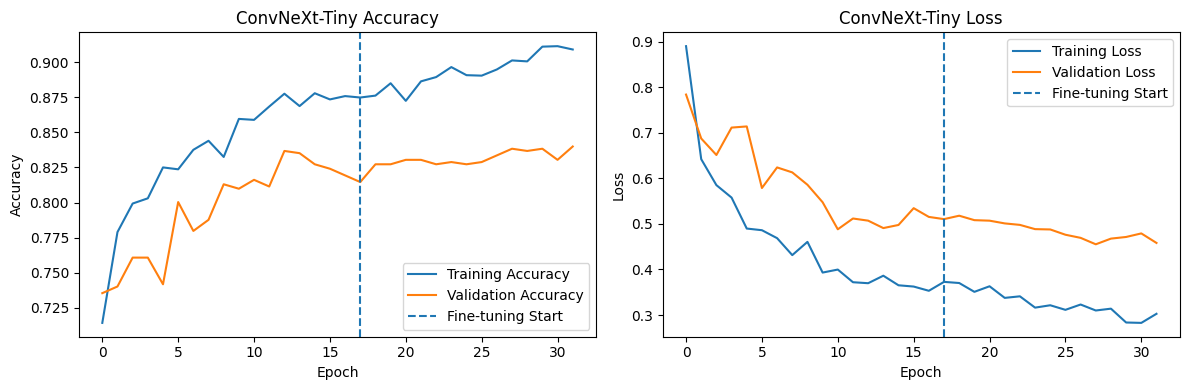

In [17]:
# ============================================================
# CONVNEXT-TINY TRAINING CURVES
# Combine Phase 1 and Phase 2 histories
# ============================================================

def combine_history(history1, history2, key):
    return history1.history[key] + history2.history[key]


train_accuracy = combine_history(
    history_phase1, history_phase2, 'accuracy'
)

val_accuracy = combine_history(
    history_phase1, history_phase2, 'val_accuracy'
)

train_loss = combine_history(
    history_phase1, history_phase2, 'loss'
)

val_loss = combine_history(
    history_phase1, history_phase2, 'val_loss'
)

# Fine-tuning starts after Phase 1
fine_tune_start = len(history_phase1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))


# -----------------------------
# Accuracy curve
# -----------------------------

axes[0].plot(train_accuracy, label='Training Accuracy')
axes[0].plot(val_accuracy, label='Validation Accuracy')

axes[0].axvline(
    x=fine_tune_start,
    linestyle='--',
    label='Fine-tuning Start'
)

axes[0].set_title('ConvNeXt-Tiny Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()


# -----------------------------
# Loss curve
# -----------------------------

axes[1].plot(train_loss, label='Training Loss')
axes[1].plot(val_loss, label='Validation Loss')

axes[1].axvline(
    x=fine_tune_start,
    linestyle='--',
    label='Fine-tuning Start'
)

axes[1].set_title('ConvNeXt-Tiny Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()


plt.tight_layout()

plt.savefig(
    '/content/convnext_tiny_training_curves.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [18]:
# ============================================================
# LOAD FINAL CONVNEXT-TINY MODEL
# Best Phase 2 model selected using validation loss
# ============================================================

final_model = tf.keras.models.load_model(
    '/content/convnext_tiny_best_phase2.keras'
)

print("Final ConvNeXt-Tiny model loaded successfully.")
print("Checkpoint: convnext_tiny_best_phase2.keras")

Final ConvNeXt-Tiny model loaded successfully.
Checkpoint: convnext_tiny_best_phase2.keras


In [19]:
# ============================================================
# FINAL TEST EVALUATION - CONVNEXT-TINY
# ============================================================

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# Evaluate the selected final model
# ------------------------------------------------------------

test_results = final_model.evaluate(
    test_ds,
    verbose=0,
    return_dict=True
)


# ------------------------------------------------------------
# Generate test predictions ONCE
# These variables will be reused in later cells
# ------------------------------------------------------------

y_true_list = []
y_pred_probs_list = []

for x_batch, y_batch in test_ds:

    probs = final_model.predict(
        x_batch,
        verbose=0
    )

    y_true_list.append(y_batch.numpy())
    y_pred_probs_list.append(probs)


y_true = np.concatenate(y_true_list, axis=0)
y_pred_probs = np.concatenate(y_pred_probs_list, axis=0)

y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)


# ------------------------------------------------------------
# Final metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_true_labels,
    y_pred_labels
)

weighted_precision = precision_score(
    y_true_labels,
    y_pred_labels,
    average='weighted',
    zero_division=0
)

weighted_recall = recall_score(
    y_true_labels,
    y_pred_labels,
    average='weighted',
    zero_division=0
)

weighted_f1 = f1_score(
    y_true_labels,
    y_pred_labels,
    average='weighted',
    zero_division=0
)

macro_f1 = f1_score(
    y_true_labels,
    y_pred_labels,
    average='macro',
    zero_division=0
)

macro_auc = roc_auc_score(
    y_true,
    y_pred_probs,
    multi_class='ovr',
    average='macro'
)

test_loss = test_results['loss']


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("========================================")
print("FINAL CONVNEXT-TINY TEST RESULTS")
print("========================================")

print(f"Number of test images : {len(y_true_labels)}")
print(f"Accuracy              : {accuracy:.4f}")
print(f"Precision (weighted)  : {weighted_precision:.4f}")
print(f"Recall (weighted)     : {weighted_recall:.4f}")
print(f"F1-score (weighted)   : {weighted_f1:.4f}")
print(f"F1-score (macro)      : {macro_f1:.4f}")
print(f"ROC-AUC (macro OvR)   : {macro_auc:.4f}")
print(f"Test loss             : {test_loss:.4f}")

print("\nCLASSIFICATION REPORT")
print("----------------------------------------")

print(
    classification_report(
        y_true_labels,
        y_pred_labels,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

FINAL CONVNEXT-TINY TEST RESULTS
Number of test images : 637
Accuracy              : 0.8509
Precision (weighted)  : 0.8625
Recall (weighted)     : 0.8509
F1-score (weighted)   : 0.8476
F1-score (macro)      : 0.8462
ROC-AUC (macro OvR)   : 0.9733
Test loss             : 0.4767

CLASSIFICATION REPORT
----------------------------------------
                      precision    recall  f1-score   support

            cataract     0.8929    0.9554    0.9231       157
diabetic_retinopathy     0.9172    0.9337    0.9254       166
            glaucoma     0.9223    0.6250    0.7451       152
              normal     0.7208    0.8765    0.7911       162

            accuracy                         0.8509       637
           macro avg     0.8633    0.8477    0.8462       637
        weighted avg     0.8625    0.8509    0.8476       637



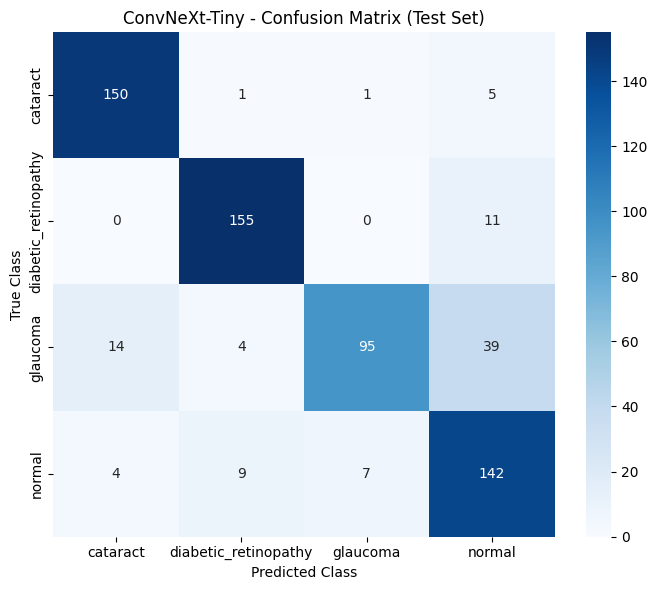

In [20]:
# ============================================================
# CONVNEXT-TINY CONFUSION MATRIX
# Final test set predictions
# ============================================================

cm = confusion_matrix(
    y_true_labels,
    y_pred_labels
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('ConvNeXt-Tiny - Confusion Matrix (Test Set)')

plt.tight_layout()

plt.savefig(
    '/content/convnext_tiny_confusion_matrix.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

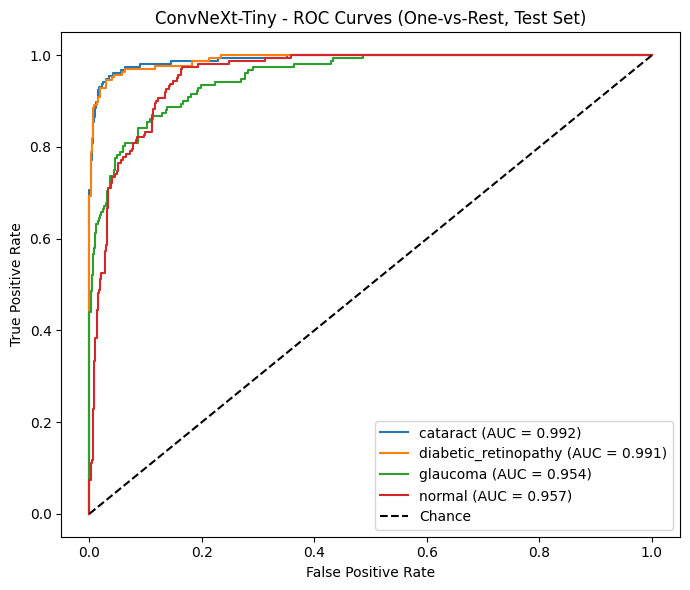

Per-class ROC-AUC
-----------------
cataract              : 0.9915
diabetic_retinopathy  : 0.9912
glaucoma              : 0.9536
normal                : 0.9568

Macro ROC-AUC (OvR) : 0.9733


In [21]:
# ============================================================
# CONVNEXT-TINY ROC CURVES
# One-vs-Rest ROC analysis on the final test predictions
# ============================================================

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Convert class labels to one-vs-rest binary format
y_true_bin = label_binarize(
    y_true_labels,
    classes=np.arange(NUM_CLASSES)
)

plt.figure(figsize=(7, 6))

class_auc_scores = {}

for i, class_name in enumerate(CLASS_NAMES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_pred_probs[:, i]
    )

    class_auc = auc(fpr, tpr)
    class_auc_scores[class_name] = class_auc

    plt.plot(
        fpr,
        tpr,
        label=f'{class_name} (AUC = {class_auc:.3f})'
    )


# Chance classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Chance'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title(
    'ConvNeXt-Tiny - ROC Curves (One-vs-Rest, Test Set)'
)

plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig(
    '/content/convnext_tiny_roc_curves.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# Display per-class and macro AUC
print("Per-class ROC-AUC")
print("-----------------")

for class_name, score in class_auc_scores.items():
    print(f"{class_name:<22}: {score:.4f}")

print(f"\nMacro ROC-AUC (OvR) : {macro_auc:.4f}")

In [22]:
# ============================================================
# CONVNEXT-TINY INFERENCE TIME
# Final selected model on the complete test set
# ============================================================

import time

# Warm-up GPU
for x_batch, _ in test_ds.take(1):
    _ = final_model.predict(
        x_batch,
        verbose=0
    )

# Measure end-to-end prediction time
start_time = time.perf_counter()

_ = final_model.predict(
    test_ds,
    verbose=0
)

end_time = time.perf_counter()

total_inference_time = end_time - start_time
num_test_images = len(y_true_labels)

inference_time_per_image = (
    total_inference_time / num_test_images
)

inference_time_ms = (
    inference_time_per_image * 1000
)

print("========================================")
print("CONVNEXT-TINY INFERENCE TIME")
print("========================================")
print(f"Number of test images     : {num_test_images}")
print(f"Total inference time      : {total_inference_time:.4f} seconds")
print(f"Inference time per image  : {inference_time_per_image:.6f} seconds")
print(f"Inference time per image  : {inference_time_ms:.2f} ms")

CONVNEXT-TINY INFERENCE TIME
Number of test images     : 637
Total inference time      : 16.5233 seconds
Inference time per image  : 0.025939 seconds
Inference time per image  : 25.94 ms


In [23]:
# ============================================================
# SAVE FINAL CONVNEXT-TINY MODEL AND RESULTS SUMMARY
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Save the final selected model
# ------------------------------------------------------------

final_model_path = '/content/convnext_tiny_eye_disease_final.keras'

final_model.save(final_model_path)


# ------------------------------------------------------------
# Create final results summary
# ------------------------------------------------------------

summary_df = pd.DataFrame([{
    'Model': 'ConvNeXt-Tiny',
    'Test Images': len(y_true_labels),

    'Test Accuracy': accuracy,
    'Weighted Precision': weighted_precision,
    'Weighted Recall': weighted_recall,
    'Weighted F1': weighted_f1,
    'Macro F1': macro_f1,
    'Macro ROC-AUC OvR': macro_auc,
    'Test Loss': test_loss,

    'Phase 1 Epochs': len(history_phase1.history['loss']),
    'Phase 2 Epochs': len(history_phase2.history['loss']),
    'Total Epochs':
        len(history_phase1.history['loss']) +
        len(history_phase2.history['loss']),

    'Phase 1 Training Time (min)':
        phase1_training_time / 60,

    'Phase 2 Training Time (min)':
        phase2_training_time / 60,

    'Total Training Time (min)':
        total_training_time / 60,

    'Inference Time per Image (ms)':
        inference_time_ms,

    'Total Parameters':
        final_model.count_params()
}])


# ------------------------------------------------------------
# Save summary as CSV
# ------------------------------------------------------------

summary_path = '/content/convnext_tiny_results_summary.csv'

summary_df.to_csv(
    summary_path,
    index=False
)


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("========================================")
print("CONVNEXT-TINY FINAL SUMMARY")
print("========================================")

print(summary_df.to_string(index=False))

print("\nSaved successfully:")
print(f"1. Final model : {final_model_path}")
print(f"2. Results CSV : {summary_path}")

print("\nNotebook pipeline completed successfully.")

CONVNEXT-TINY FINAL SUMMARY
        Model  Test Images  Test Accuracy  Weighted Precision  Weighted Recall  Weighted F1  Macro F1  Macro ROC-AUC OvR  Test Loss  Phase 1 Epochs  Phase 2 Epochs  Total Epochs  Phase 1 Training Time (min)  Phase 2 Training Time (min)  Total Training Time (min)  Inference Time per Image (ms)  Total Parameters
ConvNeXt-Tiny          637       0.850863            0.862469         0.850863     0.847639  0.846159           0.973279   0.476693              17              15            32                    17.575415                    16.699188                  34.274604                      25.939325          28021092

Saved successfully:
1. Final model : /content/convnext_tiny_eye_disease_final.keras
2. Results CSV : /content/convnext_tiny_results_summary.csv

Notebook pipeline completed successfully.
